<a href="https://colab.research.google.com/github/crowell97/ES5201/blob/main/ES5201_Lecture2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finding & Retrieving Seismic Data from the EarthScope Archive

**EARTH 5201 — Introduction to Seismology**

**The Ohio State University**

**Companion notebook to Lecture 2 — Instrumentation and Naming Conventions**

Lecture 2 covered two things that come together directly in this notebook:

1. **SEED channel naming** — the 3-character *Band / Instrument / Orientation* code (e.g. `HHZ`) that identifies every channel of seismic data archived at EarthScope (formerly the IRIS Data Management Center).
2. **The instrument response** — the transfer function $T_d(\omega)$ we derived analytically, which relates the raw digitized counts recorded by a seismometer to true ground motion.

Here we'll use [ObsPy](https://docs.obspy.org/) — the standard Python toolkit for seismology — to search the EarthScope/FDSN web services for stations and events, inspect real channel metadata and instrument responses, and download and correct waveform data.

> **Note:** the search and download cells in this notebook require internet access to EarthScope's web services (`service.earthscope.org`). They will not run in a sandboxed/offline environment — run this notebook on a machine with a normal internet connection.

## 1. Setup

ObsPy bundles an FDSN (International Federation of Digital Seismograph Networks) web-service client, which is what lets us query EarthScope programmatically instead of clicking through a web form.

In [1]:
# Run once per environment
%pip install obspy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 31.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from obspy import UTCDateTime
from obspy.clients.fdsn import Client

plt.rcParams["figure.figsize"] = (10, 4)

## 2. Connect to EarthScope

EarthScope operates the FDSN web services that used to be run by the IRIS DMC (the two organizations merged in 2023). ObsPy still recognizes the legacy shorthand `"IRIS"`, but `"EARTHSCOPE"` is now the preferred client name.

In [3]:
client = Client("EARTHSCOPE")
print(client)

FDSN Webservice Client (base url: https://service.earthscope.org)
Available Services: 'dataselect' (v1.1.74), 'station' (v1.1.56)

Use e.g. client.help('dataselect') for the
parameter description of the individual services
or client.help() for parameter description of
all webservices.


## 3. Searching for stations & decoding channel codes

Recall the SEED channel-naming convention from lecture:

| Position | Meaning | Example |
|---|---|---|
| 1st letter | **Band code** — sample rate & response band | `H` = high broadband (≥ 80–250 Hz, corner period ≥ 10 s) |
| 2nd letter | **Instrument code** — sensor family | `H` = high-gain seismometer |
| 3rd letter | **Orientation code** — measurement direction | `Z` = vertical |

So a channel code of **`HHZ`** is a high-broadband, high-gain seismometer's vertical component — one of the most common channels in global seismology.

Let's search for exactly that at a well-known Global Seismographic Network station, `IU.ANMO` (Albuquerque, New Mexico).

In [4]:
inventory = client.get_stations(
    network="IU",
    station="ANMO",
    channel="HH*",              # all three orientations: HHZ, HHN, HHE (or HH1/HH2)
    level="channel",
    starttime=UTCDateTime("2020-01-01"),
    endtime=UTCDateTime("2020-01-02"),
)
print(inventory)

Inventory created at 2026-08-27T19:31:53.411400Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.56
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=202...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (1):
			IU
		Stations (1):
			IU.ANMO (Albuquerque, New Mexico, USA)
		Channels (6):
			IU.ANMO.00.HHZ, IU.ANMO.00.HH1, IU.ANMO.00.HH2, IU.ANMO.10.HHZ, 
			IU.ANMO.10.HH1, IU.ANMO.10.HH2


In [5]:
# Decode each returned channel using the same logic as the lecture's SEED tables
for net in inventory:
    for sta in net:
        for cha in sta:
            band, instrument, orientation = cha.code[0], cha.code[1], cha.code[2]
            print(f"{net.code}.{sta.code}.{cha.location_code}.{cha.code}  "
                  f"(band={band}, instrument={instrument}, orientation={orientation}, "
                  f"sample_rate={cha.sample_rate} Hz)")

IU.ANMO.00.HH1  (band=H, instrument=H, orientation=1, sample_rate=100.0 Hz)
IU.ANMO.00.HH2  (band=H, instrument=H, orientation=2, sample_rate=100.0 Hz)
IU.ANMO.00.HHZ  (band=H, instrument=H, orientation=Z, sample_rate=100.0 Hz)
IU.ANMO.10.HH1  (band=H, instrument=H, orientation=1, sample_rate=100.0 Hz)
IU.ANMO.10.HH2  (band=H, instrument=H, orientation=2, sample_rate=100.0 Hz)
IU.ANMO.10.HHZ  (band=H, instrument=H, orientation=Z, sample_rate=100.0 Hz)


## 4. Searching geographically

You can also search by location instead of by network/station name — e.g. every broadband vertical channel within a radius of a point (useful for building a regional dataset around an earthquake or a region of interest).

In [51]:
inventory_box = client.get_stations(
    network="IU,II,US,PB",
    channel="HHZ",
    starttime=UTCDateTime("2024-12-01"),
    latitude=40.0, longitude=-112.0,
    maxradius=10,                 # degrees
    level="station",
)
print(inventory_box)

Inventory created at 2026-08-27T20:12:55.534800Z
	Created by: EarthScope WEB SERVICE: fdsnws-station | version: 1.1.56
		    https://service.earthscope.org/fdsnws/station/1/query?starttime=202...
	Sending institution: EarthScope (EarthScope)
	Contains:
		Networks (3):
			IU, PB, US
		Stations (27):
			IU.ANMO (Albuquerque, New Mexico, USA)
			IU.COR (Corvallis, Oregon, USA)
			IU.RSSD (Black Hills, South Dakota, USA)
			IU.TUC (Tucson, Arizona)
			PB.B081 (keenwi081bcs2006, Anza, CA, USA)
			PB.B082 (pathfi082bcs2006, Anza, CA, USA)
			PB.B082A (pathfi082bcs2006, Anza, CA, USA)
			PB.B084 (pinyon084bcs2006, Anza, CA, USA)
			PB.B086 (santar086bcs2006, Anza, CA, USA)
			PB.B086A (santar086bcs2006, Anza, CA, USA)
			PB.B087 (fordra087bcs2006, Anza, CA, USA)
			PB.B088 (skyoks088bcs2007, Anza, CA, USA)
			PB.B093 (trippf093bcs2007, Anza, CA, USA)
			PB.B946 (sagebf946bcs2010, Anza, CA, USA)
			US.AHID (Auburn Hatchery, Idaho, USA)
			US.BMO (Blue Mountains Array (Baker), Oregon, USA)
			U

## 5. Pulling the instrument response

This is where Lecture 2's derivation becomes concrete. Requesting `level="response"` returns the full instrument response — poles, zeros, and gain stages — that ObsPy uses to build exactly the kind of amplitude and phase response curves ($A_d(\omega)$ and $\phi(\omega)$) that we derived analytically for a damped seismometer.

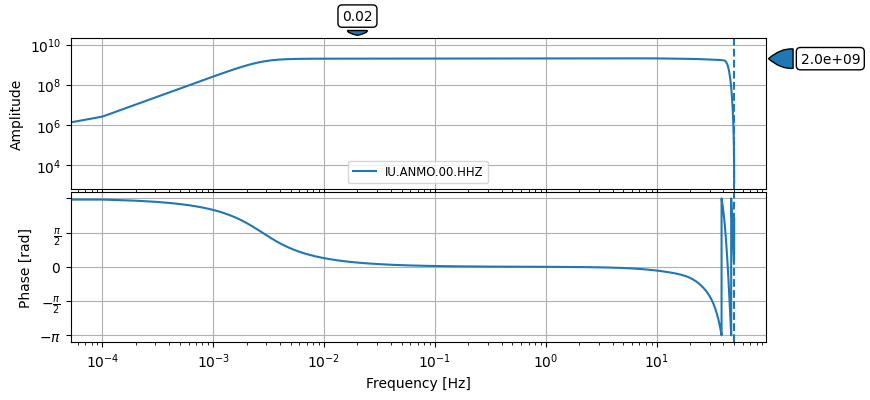

In [7]:
inv_resp = client.get_stations(
    network="IU", station="ANMO", channel="HHZ", location="00",
    starttime=UTCDateTime("2020-01-01"), endtime=UTCDateTime("2020-01-02"),
    level="response",
)

inv_resp.plot_response(min_freq=1e-4);

Compare this to the amplitude/phase response plots from lecture — same shape, same physics, just measured (and far more complex, since a real broadband sensor combines several response stages) rather than derived from a single spring-mass-dashpot model.

## 6. Searching for events

We will change clients to the USGS ComCat catalog **event** service. I'm explicitly searching for the 2024 M7.3 Cape Mendocino earthquake here (https://earthquake.usgs.gov/earthquakes/eventpage/nc75095651/executive).

In [53]:
# The EarthScope client above only offers 'dataselect' and 'station' services
# (see the print(client) output in Section 2) — it has no event/catalog service.
# Query USGS's earthquake catalog (ComCat) instead, which does support get_events().
client_events = Client("USGS")

events = client_events.get_events(
    starttime=UTCDateTime("2024-12-01"),
    endtime=UTCDateTime("2024-12-31"),
    minmagnitude=7.0,
    maxmagnitude=7.1,
)
print(events)

1 Event(s) in Catalog:
2024-12-05T18:44:21.110000Z | +40.374, -125.022 | 7.0  mw | manual


In [54]:
event = events[0]
origin = event.preferred_origin() or event.origins[0]
magnitude = event.preferred_magnitude() or event.magnitudes[0]

print(f"{origin.time}  M{magnitude.mag:.1f}  "
      f"lat={origin.latitude:.2f}, lon={origin.longitude:.2f}, depth={origin.depth/1000:.1f} km")

2024-12-05T18:44:21.110000Z  M7.0  lat=40.37, lon=-125.02, depth=10.0 km


## 7. Downloading a waveform for that event

Now we request 60 minutes of raw `HHZ` data at `ANMO` starting at the event's origin time.

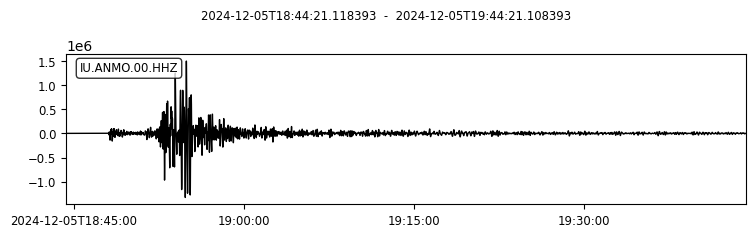

In [55]:
t0 = origin.time
st = client.get_waveforms(
    network="IU", station="ANMO", location="00", channel="HHZ",
    starttime=t0, endtime=t0 + 3600,
)
st.plot();

## 8. Removing the instrument response and filtering

The raw trace above is in **digitizer counts**, not physical units — exactly the problem Lecture 2 opened with. `remove_response()` deconvolves the instrument response we downloaded in Step 5, converting counts into true ground displacement, velocity, or acceleration.

Choosing `output="DISP"`, `"VEL"`, or `"ACC"` is the practical version of the high-frequency vs. low-frequency, displacement-vs-velocity-vs-acceleration regimes we derived from the seismometer's equation of motion.

After we remove instrument response, we use a bandpass filter between 0.02 and 10 Hz. The `zerophase=True` flag runs the filter both forwards and backwards to cancel out any phase distortion, which will preserve arrival-times.

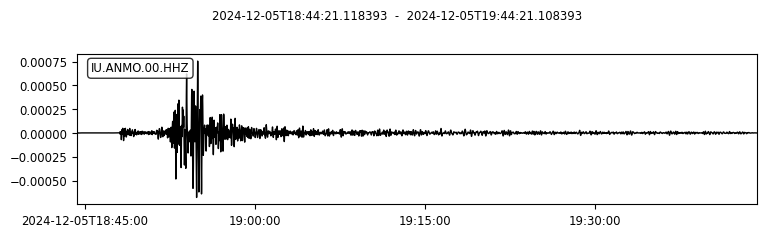

In [56]:
st_corrected = st.copy()
st_corrected.remove_response(inventory=inv_resp, output="VEL")  # counts -> ground velocity (m/s)

# 4-pole Butterworth bandpass, applied AFTER the response has been removed
st_corrected.filter("bandpass", freqmin=0.02, freqmax=10.0, corners=4, zerophase=True)

st_corrected.plot();

## 9. Putting it together

A small reusable function that combines everything above: given a station/channel and an event time, fetch the response, download the waveform, and return a response-corrected `Stream`.

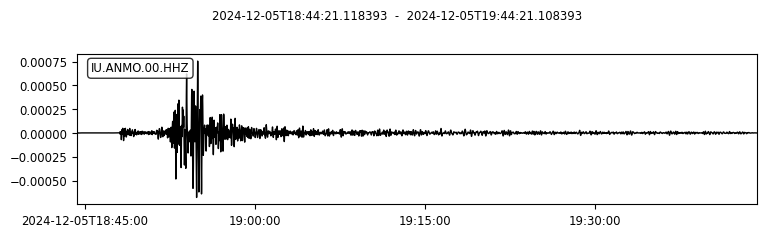

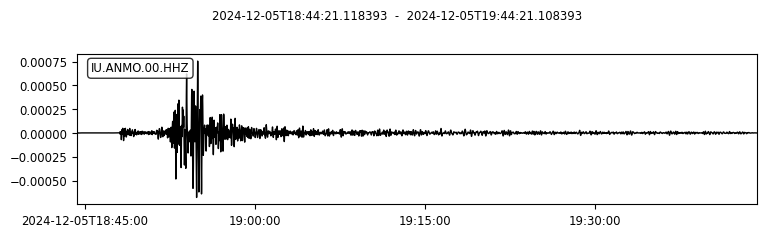

In [57]:
def fetch_event_waveform(client, network, station, location, channel,
                          event_time, pre_s=0, post_s=3600, output="VEL",
                          freqmin=0.02, freqmax=10.0, corners=4, zerophase=True):
    """Download and instrument-response-correct a waveform around an event time.

    Parameters
    ----------
    client : obspy.clients.fdsn.Client
    network, station, location, channel : str
        SEED identifiers (see Lecture 2 for how `channel` is constructed).
    event_time : obspy.UTCDateTime
        Reference time (e.g. an earthquake's origin time).
    pre_s, post_s : float
        Seconds of data to request before/after `event_time`.
    output : str
        "DISP", "VEL", or "ACC" — matches the lecture's discussion of which
        ground-motion quantity a sensor is naturally sensitive to.
    freqmin, freqmax : float
        Bandpass corner frequencies (Hz), applied AFTER the instrument
        response is removed. Set either to None to skip filtering.
    corners : int
        Number of poles for the Butterworth bandpass.
    zerophase : bool
        If True, filters forward and backward to cancel phase distortion
        (effective order is doubled, but timing is preserved — the usual
        choice when you'll pick arrivals downstream). If False, the filter
        is a single causal pass with a frequency-dependent phase delay.
    """
    t_start, t_end = event_time - pre_s, event_time + post_s

    inv = client.get_stations(network=network, station=station, channel=channel,
                               location=location, starttime=t_start, endtime=t_end,
                               level="response")
    st = client.get_waveforms(network=network, station=station, location=location,
                               channel=channel, starttime=t_start, endtime=t_end)
    st.remove_response(inventory=inv, output=output)

    if freqmin is not None and freqmax is not None:
        st.filter("bandpass", freqmin=freqmin, freqmax=freqmax,
                   corners=corners, zerophase=zerophase)

    return st, inv


# Example:
st, inv = fetch_event_waveform(client, "IU", "ANMO", "00", "HHZ", origin.time, output="VEL")
st.plot()

## 10. Further resources

- **SEED channel naming (Appendix A of the SEED manual):** https://ds.iris.edu/ds/nodes/dmc/data/formats/seed-channel-naming/
- **EarthScope "Time Series Data Channels" builder:** https://ds.iris.edu/ds/nodes/dmc/tools/data_channels
- **EarthScope data services home:** https://www.earthscope.org/data/
- **ObsPy documentation:** https://docs.obspy.org/
- **FDSN web service specifications:** https://www.fdsn.org/webservices/

Next time you see a channel code like `BHZ`, `LHN`, or `HNE` in a dataset, you should be able to read off its sample-rate band, sensor type, and orientation straight from the SEED convention — and you now have the tools to go find, download, and instrument-correct that data yourself.